# E3 - Warm-up e Regime Permanente

## Coleta de resultados em simulação estocástica

**UNIMED SP - Simulação em Serviços de Saúde**  
**Prof. Pedro Eckel**

Este notebook transforma os conceitos da apostila **E3 - Coleta de Resultados: Warm-up x Regime Permanente** em uma prática passo a passo.

A ideia central é simples: em simulação estocástica, o resultado de uma única execução não é uma verdade fixa. Ele é uma observação aleatória. Por isso, precisamos cuidar de duas coisas:

1. **Quando começar a coletar resultados**, para não misturar o estado inicial artificial com o comportamento normal do sistema.
2. **Quantas replicações executar**, para estimar médias com precisão estatística.


## Como usar este notebook

**Público:** participantes da aula E3 de Simulação em Serviços de Saúde.  
**Pré-requisitos:** média, desvio-padrão, interpretação básica de gráficos e noções de fila.  
**Exemplo usado:** uma central administrativa simplificada de autorização de procedimentos.

Ao final, você deve conseguir:

- explicar o que é viés de inicialização;
- diferenciar horizonte finito, regime permanente e regime cíclico;
- construir e interpretar um gráfico de Welch;
- calcular média, desvio-padrão, erro-padrão, intervalo de confiança (IC) de 95% e half-width;
- estimar quantas replicações são necessárias para reduzir a margem de erro.

O código foi mantido propositalmente simples. Não vamos usar SimPy neste notebook; vamos implementar uma fila pequena diretamente com `for`, `max` e algumas contas básicas.


## Jornada da aula

```text
PARTE 1 - Conceitos essenciais
  -> viés de inicialização
  -> warm-up
  -> tipos de regime de simulação

PARTE 2 - Um modelo pequeno de fila
  -> chegadas
  -> atendimento
  -> espera
  -> cálculo linha a linha

PARTE 3 - Curvas de uma replicação
  -> série de espera
  -> média móvel
  -> leitura visual do transiente

PARTE 4 - Gráfico de Welch
  -> múltiplas replicações
  -> média entre replicações
  -> suavização por média móvel

PARTE 5 - Estatística dos resultados
  -> média com e sem warm-up
  -> intervalo de confiança (IC) de 95%
  -> half-width
  -> número recomendado de replicações
```


# 1. Por que a análise de saída importa?

Quando construímos uma simulação, o modelo geralmente começa em uma condição artificial: fila vazia, recursos disponíveis, nenhum paciente ou solicitação acumulada.

Essa condição é conveniente para programar, mas nem sempre representa o sistema real.

Imagine uma central de autorização que, na vida real, já começa a manhã com solicitações pendentes do dia anterior. Se a simulação começa vazia, os primeiros atendimentos terão espera quase zero. Se incluirmos esses primeiros valores na média, o resultado ficará otimista demais.

Esse problema é chamado de **viés de inicialização**.

A solução mais comum, quando o objetivo é estudar comportamento de longo prazo, é descartar um trecho inicial da simulação. Esse trecho descartado recebe o nome de **warm-up period**.


## Glossário operacional

| Termo                 | Ideia principal                                                                            | Exemplo na UNIMED SP                                                       |
| --------------------- | ------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------- |
| Viés de inicialização | As primeiras observações refletem o estado inicial artificial, não o comportamento típico. | Fila de autorizações começa vazia no modelo, mas não no processo real.     |
| Warm-up               | Período inicial descartado antes de calcular os KPIs.                                      | Rodar 4 horas antes de coletar tempo médio de espera.                      |
| Horizonte finito      | A simulação tem início e fim naturais.                                                     | Processar um lote diário de guias até terminar o expediente.               |
| Regime permanente     | Após um transiente, as estatísticas ficam estáveis em torno de um nível.                   | Uma fila contínua idealizada, com taxas constantes.                        |
| Regime cíclico        | O sistema não estabiliza em um único valor, mas repete um padrão por ciclo.                | SAC ou central de autorização com picos por horário e dia da semana.       |
| Replicação            | Uma execução independente do mesmo modelo, com outra semente aleatória.                    | Rodar o mesmo cenário 10 vezes para estimar incerteza.                     |
| Half-width            | Metade da largura do intervalo de confiança (IC); não é o desvio-padrão.                   | Intervalo de confiança (IC) de 95% = 18,0 ± 1,2 min; half-width = 1,2 min. |


In [21]:
# CÉLULA 1 - Bibliotecas e configuração visual

import os
import tempfile
from math import ceil, sqrt

# Evita problemas de permissão dos caches gráficos em alguns ambientes.
os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="matplotlib-"))
os.environ.setdefault("XDG_CACHE_HOME", tempfile.mkdtemp(prefix="font-cache-"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except ImportError:
    stats = None

pd.set_option("display.precision", 2)
plt.style.use("seaborn-v0_8-whitegrid")

VERDE = "#007f5f"
VERDE_CLARO = "#80b918"
AZUL = "#1d4ed8"
CINZA = "#6b7280"
LARANJA = "#f97316"

print("Ambiente pronto para a prática E3.")

Ambiente pronto para a prática E3.


# 2. Exemplo pequeno: uma fila de autorização

Vamos criar uma versão mínima de uma central de autorização de procedimentos.

Hipóteses do exemplo:

- cada solicitação chega em um horário;
- existe um analista equivalente processando as solicitações em sequência;
- se o analista está livre, a solicitação começa imediatamente;
- se o analista está ocupado, a solicitação espera;
- a medida principal será o **tempo de espera em fila**, em minutos.

Este exemplo não pretende representar toda a complexidade real de uma operadora. Ele serve para enxergar, com clareza, como o warm-up afeta a coleta de resultados.


## Fórmulas linha a linha da fila

Para cada solicitação `i`, calculamos:

$$
chegada_i = chegada_{i-1} + intervalo_i
$$

$$
inicio_i = \max(chegada_i, fim_{i-1})
$$

$$
espera_i = inicio_i - chegada_i
$$

$$
fim_i = inicio_i + servico_i
$$

Interpretação:

- `chegada_i`: minuto em que a solicitação chega;
- `inicio_i`: minuto em que o atendimento começa;
- `fim_i`: minuto em que o atendimento termina;
- `espera_i`: quanto tempo a solicitação ficou aguardando.

A função `max()` é o coração da fila: o atendimento começa no maior valor entre o horário de chegada e o fim do atendimento anterior.


In [22]:
# CÉLULA 2 - Cálculo manual de uma fila com 5 solicitações

exemplo = pd.DataFrame({
    "solicitacao": [1, 2, 3, 4, 5],
    "intervalo_ate_chegar_min": [0, 2, 1, 4, 2],
    "servico_min": [5, 4, 3, 6, 2],
})

exemplo["chegada_min"] = exemplo["intervalo_ate_chegar_min"].cumsum()

inicios = []
fins = []
esperas = []

for linha in exemplo.itertuples(index=False):
    fim_anterior = 0 if len(fins) == 0 else fins[-1]
    inicio = max(linha.chegada_min, fim_anterior)
    fim = inicio + linha.servico_min
    espera = inicio - linha.chegada_min

    inicios.append(inicio)
    fins.append(fim)
    esperas.append(espera)

exemplo["inicio_min"] = inicios
exemplo["fim_min"] = fins
exemplo["espera_min"] = esperas

exemplo

,solicitacao,intervalo_ate_chegar_min,servico_min,chegada_min,inicio_min,fim_min,espera_min
0,1,0,5,0,0,5,0
1,2,2,4,2,5,9,3
2,3,1,3,3,9,12,6
3,4,4,6,7,12,18,5
4,5,2,2,9,18,20,9


## Como ler a tabela acima

Observe a solicitação 2:

- ela chega no minuto 2;
- a solicitação 1 só termina no minuto 5;
- então a solicitação 2 começa no minuto 5;
- sua espera é `5 - 2 = 3` minutos.

Observe a solicitação 5:

- ela chega no minuto 9;
- a solicitação 4 termina apenas no minuto 18;
- sua espera é `18 - 9 = 9` minutos.

Esse pequeno cálculo já mostra a mecânica de uma fila: atrasos acumulados em atendimentos anteriores geram espera para quem chega depois.


In [23]:
# CÉLULA 3 - Função simples para simular uma replicação maior

def simular_fila(semente, n_solicitacoes=160, media_intervalo=4.0, media_servico=3.2):
    """Simula uma fila simples com uma sequência de solicitações.

    media_intervalo: tempo médio entre chegadas, em minutos.
    media_servico: tempo médio de atendimento, em minutos.
    """
    rng = np.random.default_rng(semente)

    intervalos = rng.exponential(media_intervalo, size=n_solicitacoes)
    intervalos[0] = 0

    servicos = rng.exponential(media_servico, size=n_solicitacoes)

    chegadas = intervalos.cumsum()
    inicios = np.zeros(n_solicitacoes)
    fins = np.zeros(n_solicitacoes)
    esperas = np.zeros(n_solicitacoes)

    for i in range(n_solicitacoes):
        fim_anterior = 0 if i == 0 else fins[i - 1]
        inicios[i] = max(chegadas[i], fim_anterior)
        fins[i] = inicios[i] + servicos[i]
        esperas[i] = inicios[i] - chegadas[i]

    return pd.DataFrame({
        "solicitacao": np.arange(1, n_solicitacoes + 1),
        "chegada_min": chegadas,
        "servico_min": servicos,
        "inicio_min": inicios,
        "fim_min": fins,
        "espera_min": esperas,
    })

## Observação sobre as distribuições usadas

A função usa distribuições exponenciais para intervalos entre chegadas e tempos de serviço. Isso é uma simplificação didática comum em filas.

Com os valores escolhidos:

- uma solicitação chega, em média, a cada 4 minutos;
- uma solicitação leva, em média, 3,2 minutos para ser processada;
- a utilização aproximada do recurso é `3,2 / 4,0 = 0,80`, ou 80%.

Uma utilização de 80% é alta o suficiente para formar fila, mas não tão alta a ponto de tornar o sistema explosivo. Isso ajuda a enxergar o warm-up sem deixar o exemplo pesado.


In [24]:
# CÉLULA 4 - Rodando uma única replicação

rep1 = simular_fila(semente=42)

rep1.head(10)

,solicitacao,chegada_min,servico_min,inicio_min,fim_min,espera_min
0,1,0.00,0.61,0.00,0.61,0.00
1,2,9.34,4.30,9.34,13.64,0.00
2,3,18.88,3.14,18.88,22.03,0.00
3,4,20.00,0.92,22.03,22.95,2.02
4,5,20.35,1.42,22.95,24.37,2.60
5,6,26.16,2.40,26.16,28.56,0.00
6,7,31.80,6.08,31.80,37.88,0.00
7,8,44.30,1.15,44.30,45.44,0.00
8,9,44.61,2.45,45.44,47.89,0.83
9,10,48.80,1.13,48.80,49.93,0.00


## Por que a primeira replicação não basta?

A tabela anterior mostra uma única história possível da central.

Se mudarmos a semente aleatória, os intervalos entre chegadas e os tempos de serviço mudam. A média de espera também muda.

Portanto, uma replicação isolada responde apenas: "o que aconteceu neste sorteio?". Para sustentar decisão, queremos responder: "qual é o comportamento médio esperado do sistema?".


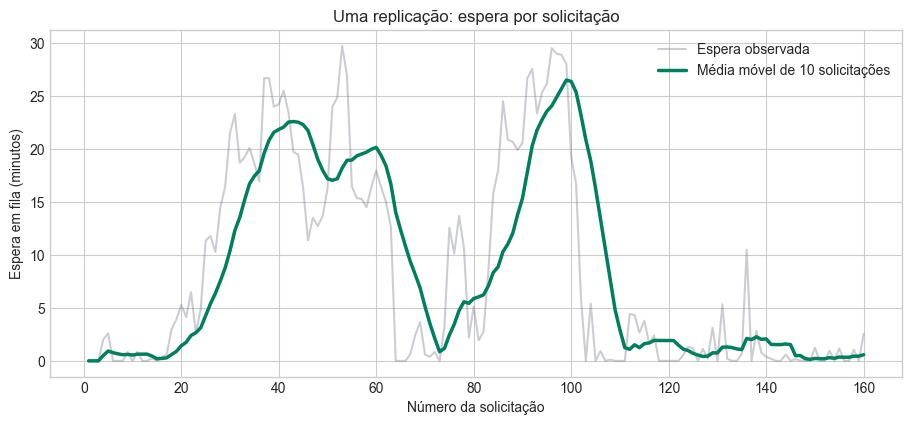

In [25]:
# CÉLULA 5 - Curva de espera de uma replicação

janela = 10
rep1["media_movel_10"] = rep1["espera_min"].rolling(window=janela, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(rep1["solicitacao"], rep1["espera_min"], color=CINZA, alpha=0.35, label="Espera observada")
ax.plot(rep1["solicitacao"], rep1["media_movel_10"], color=VERDE, linewidth=2.5, label="Média móvel de 10 solicitações")
ax.set_title("Uma replicação: espera por solicitação")
ax.set_xlabel("Número da solicitação")
ax.set_ylabel("Espera em fila (minutos)")
ax.legend()
plt.show()

## Como interpretar a curva de uma replicação

A linha cinza mostra a espera de cada solicitação. Ela é irregular porque a simulação é estocástica.

A linha verde é uma média móvel de 10 solicitações. Ela suaviza o ruído e facilita a leitura da tendência.

Mesmo assim, uma única replicação ainda é muito ruidosa. Por isso, o método de Welch usa várias replicações antes de suavizar a curva.


# 3. Múltiplas replicações

Agora vamos rodar 10 replicações independentes.

Cada replicação usa a mesma lógica, os mesmos parâmetros e uma semente diferente. Isso cria 10 histórias possíveis para o mesmo sistema.

Depois, vamos comparar as curvas e calcular a média entre replicações no mesmo número de solicitação.


In [26]:
# CÉLULA 6 - Rodando 10 replicações independentes

N_REP = 10
N_SOLICITACOES = 160

lista_reps = []

for rep in range(1, N_REP + 1):
    df_rep = simular_fila(semente=100 + rep, n_solicitacoes=N_SOLICITACOES)
    df_rep["replicacao"] = rep
    lista_reps.append(df_rep)

df_reps = pd.concat(lista_reps, ignore_index=True)

resumo_reps = (
    df_reps
    .groupby("replicacao")
    .agg(
        media_espera_min=("espera_min", "mean"),
        p90_espera_min=("espera_min", lambda x: x.quantile(0.90)),
        max_espera_min=("espera_min", "max"),
    )
)

resumo_reps

,media_espera_min,p90_espera_min,max_espera_min
replicacao,,,
1,7.19,16.84,27.23
2,8.88,20.15,40.98
3,8.82,22.20,38.16
4,13.19,29.74,40.74
5,10.26,27.72,36.73
6,9.86,28.86,51.81
7,18.48,34.19,48.85
8,6.37,16.73,28.31
9,16.29,37.06,47.80


## Leitura da tabela de replicações

Cada linha é uma execução independente do mesmo modelo.

Repare que as médias não são idênticas. Essa variação não é erro de programação; ela é a variabilidade natural da simulação estocástica.

A partir daqui, a média de cada replicação será a nossa unidade estatística para calcular o intervalo de confiança (IC).


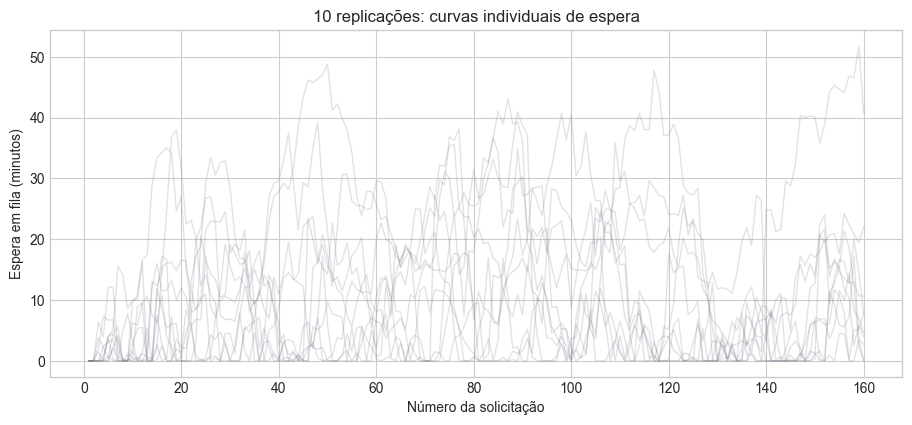

In [27]:
# CÉLULA 7 - Visualizando as 10 curvas individuais

fig, ax = plt.subplots(figsize=(11, 4.5))

for rep, grupo in df_reps.groupby("replicacao"):
    ax.plot(grupo["solicitacao"], grupo["espera_min"], color=CINZA, alpha=0.20, linewidth=1)

ax.set_title("10 replicações: curvas individuais de espera")
ax.set_xlabel("Número da solicitação")
ax.set_ylabel("Espera em fila (minutos)")
plt.show()

## O que esse gráfico mostra?

As curvas individuais se cruzam, sobem, descem e têm picos. Isso é esperado.

O objetivo do método de Welch não é escolher uma dessas curvas. O objetivo é reduzir o ruído calculando uma média entre replicações e depois suavizando essa média.


# 4. Método de Welch

O método de Welch segue três passos:

1. Rodar várias replicações independentes.
2. Para cada posição no tempo, calcular a média entre replicações.
3. Aplicar uma média móvel sobre essa série média.

Se chamarmos `Y_rj` de observação da replicação `r` na posição `j`, a média entre replicações é:

$$
\bar{Y}_{.j} = \frac{1}{R}\sum_{r=1}^{R}Y_{rj}
$$

Depois, aplicamos uma média móvel para suavizar a curva:

$$
W_j = \frac{1}{m}\sum_{k \in janela(j)}\bar{Y}_{.k}
$$

O warm-up é escolhido visualmente como o ponto a partir do qual a curva suavizada deixa de apresentar uma tendência clara de subida ou queda.


In [28]:
# CÉLULA 8 - Preparando os dados do gráfico de Welch

matriz_esperas = df_reps.pivot(
    index="solicitacao",
    columns="replicacao",
    values="espera_min",
)

welch = pd.DataFrame({
    "solicitacao": matriz_esperas.index,
    "media_entre_reps": matriz_esperas.mean(axis=1),
})

for janela in [5, 10, 20]:
    welch[f"media_movel_{janela}"] = (
        welch["media_entre_reps"]
        .rolling(window=janela, center=True, min_periods=1)
        .mean()
    )

welch.head(10)

,solicitacao,media_entre_reps,media_movel_5,media_movel_10,media_movel_20
solicitacao,,,,,
1,1,0.00,0.46,1.30,2.09
2,2,0.00,0.76,1.77,2.28
3,3,1.37,1.30,1.96,2.59
4,4,1.69,2.12,1.96,2.67
5,5,3.47,2.75,1.94,2.92
6,6,4.10,2.86,2.09,3.41
7,7,3.12,2.88,2.51,3.94
8,8,1.94,2.88,3.11,4.37
9,9,1.77,2.89,3.33,4.77


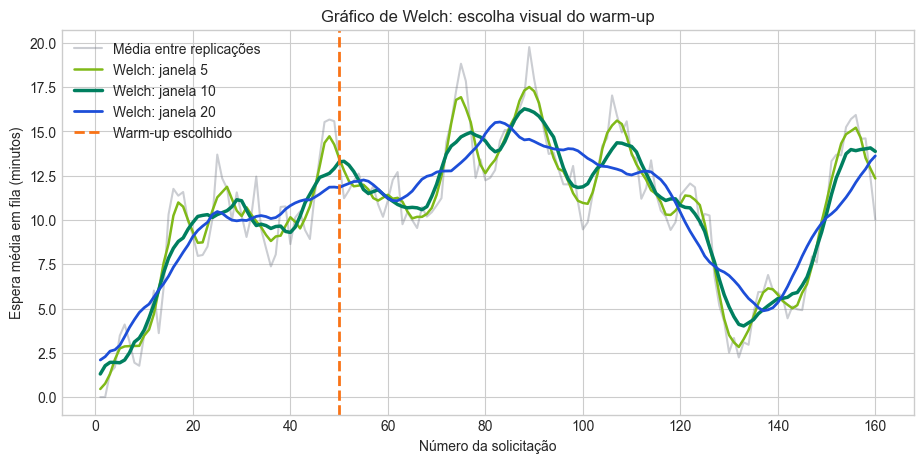

In [29]:
# CÉLULA 9 - Gráfico de Welch com janelas diferentes

WARMUP_SOLICITACOES = 50

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(welch["solicitacao"], welch["media_entre_reps"], color=CINZA, alpha=0.35, label="Média entre replicações")
ax.plot(welch["solicitacao"], welch["media_movel_5"], color=VERDE_CLARO, linewidth=1.8, label="Welch: janela 5")
ax.plot(welch["solicitacao"], welch["media_movel_10"], color=VERDE, linewidth=2.5, label="Welch: janela 10")
ax.plot(welch["solicitacao"], welch["media_movel_20"], color=AZUL, linewidth=2.0, label="Welch: janela 20")
ax.axvline(WARMUP_SOLICITACOES, color=LARANJA, linestyle="--", linewidth=2, label="Warm-up escolhido")

ax.set_title("Gráfico de Welch: escolha visual do warm-up")
ax.set_xlabel("Número da solicitação")
ax.set_ylabel("Espera média em fila (minutos)")
ax.legend(loc="upper left")
plt.show()

## Interpretação do gráfico de Welch

A leitura correta não é procurar uma linha perfeitamente horizontal. Em simulação estocástica, isso raramente acontece.

O que procuramos é o fim de uma tendência inicial clara. No exemplo, as primeiras solicitações tendem a ter espera baixa porque a simulação começa vazia. Depois, a fila passa a operar em um nível mais representativo.

Para esta prática, adotaremos:

```text
warm-up = primeiras 50 solicitações
```

Isso significa que as solicitações 1 a 50 serão usadas para aquecer o sistema, mas não entrarão no cálculo dos KPIs finais.

Em um projeto real, esta escolha deveria ser revisada com mais replicações, outras janelas de média móvel e conhecimento operacional do processo.


In [30]:
# CÉLULA 10 - Conferindo valores da curva em pontos selecionados

pontos = [10, 30, 50, 80, 120, 160]

consulta_welch = (
    welch
    .set_index("solicitacao")
    .loc[pontos, ["media_entre_reps", "media_movel_5", "media_movel_10", "media_movel_20"]]
)

consulta_welch

,media_entre_reps,media_movel_5,media_movel_10,media_movel_20
solicitacao,,,,
10,3.49,3.47,3.79,5.04
30,10.26,10.22,11.09,9.99
50,13.30,13.49,13.28,11.83
80,12.24,12.64,14.46,14.88
120,11.39,10.90,10.83,10.43
160,10.02,12.34,13.87,13.62


## Por que testar janelas diferentes?

Uma janela pequena, como 5, reage rápido, mas ainda carrega muito ruído.

Uma janela grande, como 20, fica mais suave, mas pode esconder mudanças reais.

A apostila recomenda comparar janelas porque um warm-up confiável não deveria depender totalmente de uma única escolha arbitrária de suavização.


# 5. Média com e sem warm-up

Agora vamos medir o impacto prático do descarte inicial.

Para cada replicação, calcularemos duas médias:

1. **Média completa:** usa todas as 160 solicitações.
2. **Média pós-warm-up:** descarta as primeiras 50 solicitações.

A pergunta é:

> Quanto a média muda quando removemos o período inicial artificialmente favorável?


In [31]:
# CÉLULA 11 - Comparando médias completas e médias após warm-up

media_completa = df_reps.groupby("replicacao")["espera_min"].mean()

media_pos_warmup = (
    df_reps[df_reps["solicitacao"] > WARMUP_SOLICITACOES]
    .groupby("replicacao")["espera_min"]
    .mean()
)

comparativo_warmup = pd.DataFrame({
    "media_completa_min": media_completa,
    "media_pos_warmup_min": media_pos_warmup,
})

comparativo_warmup["diferenca_min"] = (
    comparativo_warmup["media_pos_warmup_min"]
    - comparativo_warmup["media_completa_min"]
)

comparativo_warmup

,media_completa_min,media_pos_warmup_min,diferenca_min
replicacao,,,
1,7.19,7.65,0.46
2,8.88,10.39,1.51
3,8.82,8.91,0.09
4,13.19,15.39,2.21
5,10.26,10.54,0.27
6,9.86,11.26,1.40
7,18.48,18.29,-0.20
8,6.37,7.39,1.02
9,16.29,17.61,1.33


In [32]:
# CÉLULA 12 - Resumo do impacto do warm-up

resumo_warmup = pd.DataFrame({
    "metrica": ["Média das replicações sem descarte", "Média das replicações após warm-up", "Diferença"],
    "valor_min": [
        comparativo_warmup["media_completa_min"].mean(),
        comparativo_warmup["media_pos_warmup_min"].mean(),
        comparativo_warmup["diferenca_min"].mean(),
    ],
})

resumo_warmup

,metrica,valor_min
0,Média das replicações sem descarte,10.47
1,Média das replicações após warm-up,11.34
2,Diferença,0.87


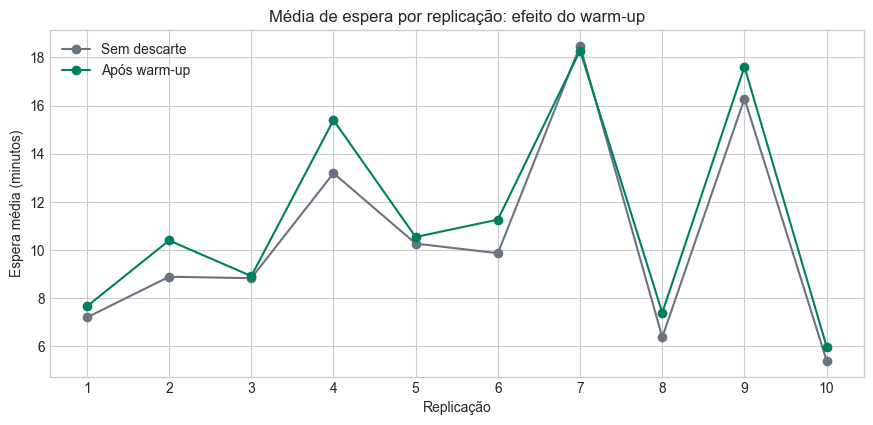

In [33]:
# CÉLULA 13 - Gráfico comparando as médias por replicação

fig, ax = plt.subplots(figsize=(10.5, 4.5))

ax.plot(comparativo_warmup.index, comparativo_warmup["media_completa_min"], marker="o", color=CINZA, label="Sem descarte")
ax.plot(comparativo_warmup.index, comparativo_warmup["media_pos_warmup_min"], marker="o", color=VERDE, label="Após warm-up")

ax.set_title("Média de espera por replicação: efeito do warm-up")
ax.set_xlabel("Replicação")
ax.set_ylabel("Espera média (minutos)")
ax.set_xticks(comparativo_warmup.index)
ax.legend()
plt.show()

## Interpretação do comparativo

Se a média pós-warm-up for maior que a média completa, isso indica que o período inicial estava puxando a estimativa para baixo.

Esse é exatamente o efeito esperado quando a simulação começa com fila vazia.

O ponto importante não é que o warm-up sempre aumenta a média. O ponto importante é que ele remove uma parte da simulação que não representa a condição operacional que queremos medir.


## Antes da seção 6: termos estatísticos que vamos usar

Antes de calcular o intervalo de confiança (IC), precisamos separar bem os papéis de cada termo.

| Termo                              |   Símbolo no notebook | O que significa                                                 | Leitura simples                                   |
| ---------------------------------- | --------------------: | --------------------------------------------------------------- | ------------------------------------------------- |
| Replicações                        |                   `n` | Quantas vezes rodamos o mesmo modelo com sementes diferentes.   | Mais replicações geram mais informação.           |
| Média das médias                   |        `media` ou `x̄` | Média das médias obtidas em cada replicação.                    | É a nossa melhor estimativa pontual.              |
| Desvio-padrão entre replicações    |       `s` ou `desvio` | Mede quanto as médias das replicações variam entre si.          | Mostra a dispersão dos resultados.                |
| Erro-padrão                        | `SE` ou `erro_padrao` | É o desvio-padrão dividido por `raiz(n)`.                       | Mede a incerteza da média estimada.               |
| Valor crítico t                    |           `t_critico` | Fator da distribuição t de Student usado para 95% de confiança. | Aumenta a margem quando temos poucas replicações. |
| Half-width                         |   `h` ou `half_width` | Margem do intervalo de confiança (IC).                          | É o valor que aparece depois do `±`.              |
| Intervalo de confiança (IC) de 95% |  `media ± half_width` | Faixa calculada ao redor da média.                              | Mostra a precisão estatística da estimativa.      |

A confusão mais comum é achar que **half-width é desvio-padrão**. Não é.

```text
desvio-padrão = dispersão das médias das replicações
erro-padrão = desvio-padrão / raiz(n)
half-width = t crítico × erro-padrão
```

Portanto, o desvio-padrão é uma matéria-prima do cálculo. O half-width é o resultado final usado como margem do intervalo de confiança (IC).


# 6. Intervalo de confiança (IC) de 95%

Depois de definido o warm-up, cada replicação gera uma média de espera pós-warm-up.

Essas médias são tratadas como observações independentes:

```text
replicação 1 -> média pós-warm-up
replicação 2 -> média pós-warm-up
...
replicação n -> média pós-warm-up
```

Com elas, calculamos:

$$
\bar{x} = \text{média das médias das replicações}
$$

$$
s = \text{desvio-padrão amostral entre replicações}
$$

$$
SE = \frac{s}{\sqrt{n}}
$$

$$
h = t_{0,975;n-1}\cdot SE
$$

$$
\text{IC}_{95\%} = \bar{x} \pm h
$$

O valor `h` é o **half-width**, isto é, a margem de erro estatística do intervalo de confiança (IC). Ele **não é o desvio-padrão**; ele é calculado a partir do desvio-padrão, do número de replicações e do valor crítico da distribuição t.


## Por que usamos a distribuição t de Student?

Nesta parte do notebook, queremos estimar a **média verdadeira de espera do modelo**. Mas temos um problema: não conhecemos essa média verdadeira. Só temos as médias observadas nas replicações.

Por exemplo:

```text
Replicação 1 -> média pós-warm-up = 9,8 min
Replicação 2 -> média pós-warm-up = 12,1 min
Replicação 3 -> média pós-warm-up = 10,7 min
...
```

A partir dessas replicações, calculamos uma média geral. Porém, essa média ainda tem incerteza. Se rodássemos outras 10 replicações, provavelmente obteríamos uma média um pouco diferente.

A distribuição **t de Student** entra exatamente aqui: ela é usada para construir o intervalo de confiança (IC) quando estimamos uma média a partir de uma amostra pequena e não conhecemos o desvio-padrão verdadeiro da população.

### Por que não usar simplesmente 1,96?

O número `1,96` vem da distribuição Normal padrão e aparece muito em intervalos de 95%.

Mas ele é adequado principalmente quando:

- temos muitas observações; ou
- conhecemos o desvio-padrão verdadeiro da população.

Na simulação, normalmente não conhecemos o desvio-padrão verdadeiro do modelo. Nós estimamos esse desvio-padrão usando as próprias replicações. Quando `n` é pequeno, essa estimativa ainda é incerta.

Por isso usamos a distribuição t de Student, que é mais conservadora: ela abre um pouco mais o intervalo de confiança (IC) para compensar a incerteza adicional.

### O que significa `t(0,975; n - 1)`?

No notebook aparece esta ideia:

$$
h = t_{0,975;n-1}\cdot \frac{s}{\sqrt{n}}
$$

Leia assim:

| Parte             | Significado                                                |
| ----------------- | ---------------------------------------------------------- |
| `h`               | half-width, a margem do intervalo de confiança (IC).       |
| `s`               | desvio-padrão amostral entre as médias das replicações.    |
| `n`               | número de replicações.                                     |
| `sqrt(n)`         | raiz quadrada de `n`.                                      |
| `s / sqrt(n)`     | erro-padrão da média.                                      |
| `t(0,975; n - 1)` | valor crítico da distribuição t de Student para IC de 95%. |

O `0,975` aparece porque o intervalo de confiança (IC) de 95% deixa 5% de probabilidade fora do intervalo: 2,5% na cauda esquerda e 2,5% na cauda direita.

```text
95% no centro
2,5% na esquerda
2,5% na direita

1 - 0,025 = 0,975
```

Por isso usamos o quantil `0,975`.

### O que são graus de liberdade?

No intervalo de confiança (IC), os graus de liberdade são:

$$
gl = n - 1
$$

Se temos 10 replicações:

```text
n = 10
graus de liberdade = 10 - 1 = 9
```

Usamos `n - 1` porque, ao calcular o desvio-padrão amostral, uma informação já foi usada para estimar a média. Em termos intuitivos: depois que a média é fixada, nem todos os valores podem variar livremente.

### O que acontece quando aumentamos o número de replicações?

Quanto mais replicações usamos, mais a t de Student se aproxima da Normal.

| Replicações `n` | Graus de liberdade `n - 1` | t crítico aproximado para IC 95% |
| --------------: | -------------------------: | -------------------------------: |
|               2 |                          1 |                           12,706 |
|               5 |                          4 |                            2,776 |
|              10 |                          9 |                            2,262 |
|              30 |                         29 |                            2,045 |
|          Muitas |               Muito grande |                  Próximo de 1,96 |

A leitura é simples:

- com poucas replicações, há pouca informação, então a margem precisa ser maior;
- com muitas replicações, há mais informação, então a margem pode ser menor;
- no limite, a t de Student fica muito parecida com a Normal.

### Por que tem esse nome?

A distribuição recebeu esse nome por causa do pseudônimo **Student**.

O estatístico William Sealy Gosset trabalhava na cervejaria Guinness, no início do século XX. A empresa tinha restrições para publicações técnicas dos funcionários. Por isso, Gosset publicou seu trabalho usando o pseudônimo **Student**.

Com o tempo, a distribuição apresentada por ele ficou conhecida como **distribuição t de Student**.

Portanto, “Student” não significa estudante no sentido comum da palavra aqui. É o pseudônimo usado pelo autor que desenvolveu essa distribuição.

### Resumo em uma frase

Usamos a t de Student porque estamos estimando a média com um número limitado de replicações e com desvio-padrão desconhecido; ela aumenta a margem do intervalo de confiança (IC) para refletir essa incerteza.


In [34]:
# CÉLULA 14 - Função para obter t crítico de 95%

T_CRITICO_975 = {
    1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
    6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
    11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
    16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
    21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
    26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042,
}


def t_critico_95(n):
    """Retorna t(0,975; n-1). Usa SciPy quando disponível."""
    graus_liberdade = n - 1

    if stats is not None:
        return stats.t.ppf(0.975, graus_liberdade)

    return T_CRITICO_975.get(graus_liberdade, 1.96)

In [35]:
# CÉLULA 15 - Cálculo passo a passo do intervalo de confiança (IC) de 95%

medias = comparativo_warmup["media_pos_warmup_min"]

n = len(medias)
media = medias.mean()
desvio = medias.std(ddof=1)
erro_padrao = desvio / sqrt(n)
t_critico = t_critico_95(n)
half_width = t_critico * erro_padrao
limite_inferior = media - half_width
limite_superior = media + half_width

ic95 = pd.DataFrame({
    "passo": [
        "n",
        "média das médias",
        "desvio-padrão entre replicações",
        "erro-padrão",
        "t crítico 95%",
        "half-width (margem do IC)",
        "limite inferior",
        "limite superior",
    ],
    "valor": [
        n,
        media,
        desvio,
        erro_padrao,
        t_critico,
        half_width,
        limite_inferior,
        limite_superior,
    ],
})

ic95

,passo,valor
0,n,10.00
1,média das médias,11.34
2,desvio-padrão entre replicações,4.34
3,erro-padrão,1.37
4,t crítico 95%,2.26
5,half-width (margem do IC),3.10
6,limite inferior,8.24
7,limite superior,14.45


In [36]:
# CÉLULA 16 - Mostrando o intervalo de confiança (IC) de 95% em uma frase

print(f"Espera média pós-warm-up: {media:.2f} minutos")
print(f"Intervalo de confiança (IC) de 95%: [{limite_inferior:.2f}, {limite_superior:.2f}] minutos")
print(f"Forma compacta: {media:.2f} ± {half_width:.2f} minutos")

Espera média pós-warm-up: 11.34 minutos
Intervalo de confiança (IC) de 95%: [8.24, 14.45] minutos
Forma compacta: 11.34 ± 3.10 minutos


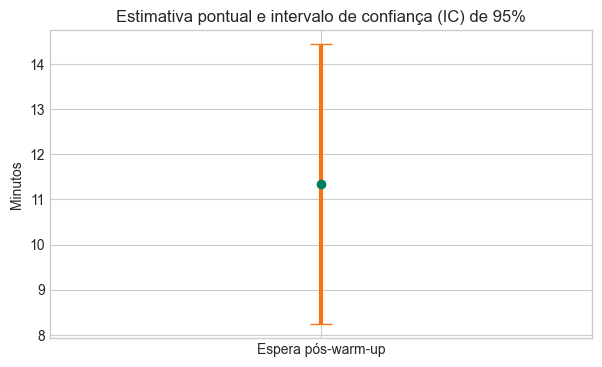

In [37]:
# CÉLULA 17 - Visualizando a estimativa e o intervalo de confiança (IC) de 95%

fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(
    x=[1],
    y=[media],
    yerr=[half_width],
    fmt="o",
    color=VERDE,
    ecolor=LARANJA,
    elinewidth=3,
    capsize=8,
)

ax.set_xlim(0.5, 1.5)
ax.set_xticks([1])
ax.set_xticklabels(["Espera pós-warm-up"])
ax.set_ylabel("Minutos")
ax.set_title("Estimativa pontual e intervalo de confiança (IC) de 95%")
plt.show()

## Como interpretar o intervalo de confiança (IC) de 95%

O intervalo de confiança (IC) não diz que há 95% de probabilidade de a média verdadeira estar dentro deste intervalo específico.

A interpretação frequente correta é:

> Se repetíssemos esse procedimento muitas vezes, cerca de 95% dos intervalos construídos dessa forma conteriam a média verdadeira do modelo.

Para tomada de decisão, o half-width é especialmente útil porque transforma a variabilidade das replicações em margem do intervalo de confiança (IC). Ele responde:

> Qual é a margem de erro estatística da minha estimativa?


## Antes da seção 7: termos da fórmula de replicações

A seção 7 usa o half-width para responder: **quantas replicações preciso rodar para atingir uma margem menor?**

A fórmula é:

$$
n \approx n_0\left(\frac{h_0}{h}\right)^2
$$

Leia cada símbolo assim:

| Símbolo | Nome                         | O que significa                                                       |
| ------: | ---------------------------- | --------------------------------------------------------------------- |
|    `n0` | Replicações atuais           | Quantas replicações já foram usadas no cálculo atual.                 |
|    `h0` | Half-width atual             | A margem atual do intervalo de confiança (IC). Não é o desvio-padrão. |
|     `h` | Half-width desejado          | A margem que queremos atingir. Exemplo: reduzir para `±1 minuto`.     |
|     `n` | Replicações totais estimadas | Quantas replicações seriam necessárias no total.                      |

Exemplo de leitura:

```text
Tenho 10 replicações e half-width atual de 3,10 minutos.
Quero half-width de 1,00 minuto.
A fórmula estima quantas replicações totais eu deveria rodar.
```

A mensagem central é: quanto menor a margem desejada, maior o número de replicações necessárias.


# 7. Quantas replicações são necessárias?

A apostila apresenta a fórmula aproximada:

$$
n \approx n_0\left(\frac{h_0}{h}\right)^2
$$

em que:

- `n0` é o número atual de replicações;
- `h0` é o half-width atual, isto é, a margem atual do intervalo de confiança (IC), não o desvio-padrão;
- `h` é o half-width desejado.

Essa fórmula mostra uma propriedade importante: reduzir a margem de erro pela metade exige aproximadamente quatro vezes mais replicações.


In [38]:
# CÉLULA 18 - Estimando replicações necessárias para uma margem desejada

half_width_desejado = 1.0

n_necessario = ceil(n * (half_width / half_width_desejado) ** 2)
replicacoes_adicionais = max(n_necessario - n, 0)

pd.DataFrame({
    "item": [
        "replicações atuais",
        "half-width atual: margem do IC (min)",
        "half-width desejado: margem do IC (min)",
        "replicações totais estimadas",
        "replicações adicionais estimadas",
    ],
    "valor": [
        n,
        half_width,
        half_width_desejado,
        n_necessario,
        replicacoes_adicionais,
    ],
})

,item,valor
0,replicações atuais,10.0
1,half-width atual: margem do IC (min),3.1
2,half-width desejado: margem do IC (min),1.0
3,replicações totais estimadas,97.0
4,replicações adicionais estimadas,87.0


## Verificação prática da quantidade estimada

A fórmula da seção anterior é uma **aproximação**. Ela usa o half-width observado nas primeiras replicações para estimar quantas replicações seriam necessárias para atingir a margem desejada.

Agora vamos testar a ideia na prática:

1. Rodar `n_necessario` replicações no total.
2. Aplicar o mesmo warm-up escolhido.
3. Recalcular o intervalo de confiança (IC) de 95%.
4. Conferir se o novo half-width ficou próximo ou abaixo de `half_width_desejado`.
5. Se não atingir, continuar aumentando o número de replicações até encontrar o primeiro `n` que atinge a margem desejada.

Esse passo é importante porque a fórmula depende do desvio-padrão observado inicialmente. Quando rodamos mais replicações, o desvio-padrão pode mudar. Por isso, em um estudo real, a escolha do número final de replicações costuma ser iterativa.


In [39]:
# CÉLULA 18B - Verificando se a quantidade estimada atinge a margem desejada

N_VERIFICACAO = max(n_necessario, n)
N_MAX_BUSCA = max(5 * N_VERIFICACAO, 500)

medias_verificacao = []
primeiro_n_que_atingiu = None
half_width_no_n_estimado = None
media_no_n_estimado = None
ic_inferior_no_n_estimado = None
ic_superior_no_n_estimado = None
half_width_final = None

for rep in range(1, N_MAX_BUSCA + 1):
    df_rep = simular_fila(
        semente=1000 + rep,
        n_solicitacoes=N_SOLICITACOES,
    )

    media_rep = df_rep[df_rep["solicitacao"] > WARMUP_SOLICITACOES]["espera_min"].mean()
    medias_verificacao.append(media_rep)

    if rep < 2:
        continue

    serie_medias = pd.Series(medias_verificacao)
    media_teste = serie_medias.mean()
    desvio_teste = serie_medias.std(ddof=1)
    erro_padrao_teste = desvio_teste / sqrt(rep)
    half_width_teste = t_critico_95(rep) * erro_padrao_teste

    if rep == N_VERIFICACAO:
        half_width_no_n_estimado = half_width_teste
        media_no_n_estimado = media_teste
        ic_inferior_no_n_estimado = media_teste - half_width_teste
        ic_superior_no_n_estimado = media_teste + half_width_teste

    if primeiro_n_que_atingiu is None and half_width_teste <= half_width_desejado:
        primeiro_n_que_atingiu = rep
        half_width_final = half_width_teste

    if rep >= N_VERIFICACAO and primeiro_n_que_atingiu is not None:
        break

atingiu_no_n_estimado = half_width_no_n_estimado <= half_width_desejado

pd.DataFrame({
    "item": [
        "replicações estimadas pela fórmula",
        "half-width desejado: margem do IC (min)",
        "half-width obtido com n estimado (min)",
        "média com n estimado (min)",
        "limite inferior do IC 95% com n estimado (min)",
        "limite superior do IC 95% com n estimado (min)",
        "atingiu com n estimado?",
        "primeiro n que atingiu a margem na busca",
        "half-width nesse primeiro n (min)",
    ],
    "valor": [
        N_VERIFICACAO,
        half_width_desejado,
        half_width_no_n_estimado,
        media_no_n_estimado,
        ic_inferior_no_n_estimado,
        ic_superior_no_n_estimado,
        "sim" if atingiu_no_n_estimado else "não",
        primeiro_n_que_atingiu if primeiro_n_que_atingiu is not None else "não encontrado até o limite",
        half_width_final if half_width_final is not None else np.nan,
    ],
})

,item,valor
0,replicações estimadas pela fórmula,97
1,half-width desejado: margem do IC (min),1.0
2,half-width obtido com n estimado (min),1.7
3,média com n estimado (min),12.06
4,limite inferior do IC 95% com n estimado (min),10.36
5,limite superior do IC 95% com n estimado (min),13.77
6,atingiu com n estimado?,não
7,primeiro n que atingiu a margem na busca,307
8,half-width nesse primeiro n (min),1.0


## Como interpretar a verificação

A linha **“atingiu com n estimado?”** responde diretamente à pergunta: usando a quantidade calculada pela fórmula, o half-width ficou abaixo da margem desejada?

Se aparecer `sim`, a estimativa foi suficiente nesta verificação.

Se aparecer `não`, observe a linha **“primeiro n que atingiu a margem na busca”**. Ela mostra quantas replicações foram necessárias, nesta sequência de sorteios, para que o half-width ficasse menor ou igual à margem desejada.

Isso não significa que a fórmula esteja errada. Significa que ela é uma aproximação baseada no desvio-padrão inicial. Quando novas replicações entram, a variabilidade observada pode aumentar ou diminuir.

A leitura correta é:

```text
A fórmula fornece uma estimativa inicial.
A verificação com mais replicações confirma se a margem desejada foi atingida.
Se não foi, continuamos rodando até atingir a precisão desejada.
```

Em projetos reais, esse processo costuma ser iterativo: estima-se `n`, roda-se mais replicações, recalcula-se o intervalo de confiança (IC) e, se necessário, aumenta-se novamente `n`.


## Leitura gerencial

Se o half-width atual for grande, a média ainda está muito incerta para decisões finas. Isso não significa necessariamente que o desvio-padrão seja o próprio half-width; significa que a margem do intervalo de confiança (IC) ficou ampla.

Por exemplo, se dois cenários diferem em apenas 1 minuto de espera média, mas o intervalo de confiança (IC) de 95% tem margem de 3 minutos, a comparação é frágil.

Nesse caso, há três caminhos:

- aumentar o número de replicações;
- reduzir a variabilidade do experimento com melhor controle do modelo;
- aceitar que a evidência disponível só sustenta conclusões mais gerais.


# 8. Horizonte finito, regime permanente e regime cíclico

Nem toda simulação precisa de warm-up.

A decisão depende do tipo de sistema e da pergunta de pesquisa.


In [40]:
# CÉLULA 19 - Quadro de decisão inspirado na apostila

quadro_regimes = pd.DataFrame({
    "tipo": ["Horizonte finito", "Regime permanente", "Regime cíclico"],
    "quando_usar": [
        "Existe início e fim natural do processo.",
        "Queremos o comportamento típico de longo prazo.",
        "Existe padrão repetitivo, mas não um único nível constante.",
    ],
    "warmup": [
        "Geralmente não se aplica.",
        "Aplica-se para remover o transiente inicial.",
        "Pode ser usado para remover partida vazia, mas a análise é por ciclo.",
    ],
    "exemplo_unimed": [
        "Lote diário de guias e reembolsos.",
        "Fila contínua idealizada com taxas constantes.",
        "SAC ou central de autorização com picos por horário.",
    ],
})

quadro_regimes

,tipo,quando_usar,warmup,exemplo_unimed
0,Horizonte finito,Existe início e fim natural do processo.,Geralmente não se aplica.,Lote diário de guias e reembolsos.
1,Regime permanente,Queremos o comportamento típico de longo prazo.,Aplica-se para remover o transiente inicial.,Fila contínua idealizada com taxas constantes.
2,Regime cíclico,"Existe padrão repetitivo, mas não um único nív...","Pode ser usado para remover partida vazia, mas...",SAC ou central de autorização com picos por ho...


## Regra prática de escolha

Use esta pergunta:

> O período inicial vazio faz parte do fenômeno real que eu quero estudar?

Se a resposta for **sim**, provavelmente é horizonte finito e não devemos descartar o início.

Se a resposta for **não**, e o início vazio só existe porque programamos o modelo assim, provavelmente precisamos discutir warm-up.

Se o sistema tem picos previsíveis por hora ou dia, a análise deve respeitar o ciclo. Nesse caso, não buscamos uma linha horizontal única, mas um perfil médio por ciclo.


# 9. Exercício guiado

Use as células abaixo para testar sua interpretação.

Tarefa:

1. Troque `WARMUP_EXERCICIO` para 30, 50 e 70.
2. Observe como mudam a média, o intervalo de confiança (IC) de 95% e o half-width.
3. Troque `HALF_WIDTH_DESEJADO` para 0,5 e 2,0 minutos.
4. Compare o número de replicações recomendado.

Perguntas para responder:

- Um warm-up menor parece deixar a média mais otimista?
- Um warm-up maior reduz ou aumenta a incerteza?
- Por que exigir uma margem de erro menor aumenta tanto o número de replicações?


In [41]:
# CÉLULA 20 - Exercício: altere os dois valores abaixo

WARMUP_EXERCICIO = 50
HALF_WIDTH_DESEJADO = 1.0

medias_exercicio = (
    df_reps[df_reps["solicitacao"] > WARMUP_EXERCICIO]
    .groupby("replicacao")["espera_min"]
    .mean()
)

n_ex = len(medias_exercicio)
media_ex = medias_exercicio.mean()
desvio_ex = medias_exercicio.std(ddof=1)
erro_padrao_ex = desvio_ex / sqrt(n_ex)
t_ex = t_critico_95(n_ex)
h_ex = t_ex * erro_padrao_ex
n_estimado_ex = ceil(n_ex * (h_ex / HALF_WIDTH_DESEJADO) ** 2)

pd.DataFrame({
    "medida": [
        "warm-up usado",
        "replicações",
        "média pós-warm-up",
        "desvio-padrão entre replicações",
        "half-width atual: margem do IC",
        "half-width desejado: margem do IC",
        "replicações totais estimadas",
    ],
    "valor": [
        WARMUP_EXERCICIO,
        n_ex,
        media_ex,
        desvio_ex,
        h_ex,
        HALF_WIDTH_DESEJADO,
        n_estimado_ex,
    ],
})

,medida,valor
0,warm-up usado,50.00
1,replicações,10.00
2,média pós-warm-up,11.34
3,desvio-padrão entre replicações,4.34
4,half-width atual: margem do IC,3.10
5,half-width desejado: margem do IC,1.00
6,replicações totais estimadas,97.00


## Resposta esperada do exercício

Você deve observar três padrões:

1. **Warm-up muito curto** tende a manter parte do transiente inicial na amostra, podendo puxar a média para baixo.
2. **Warm-up muito longo** reduz o número de observações dentro de cada replicação. Isso pode aumentar a variabilidade das médias por replicação.
3. **Half-width desejado menor** aumenta fortemente o número de replicações necessárias, porque a fórmula depende do quadrado da razão `h0 / h`.

A decisão técnica não deve ser automática. Ela combina gráfico, estatística e conhecimento operacional do processo real.


# 10. Armadilhas comuns

| Armadilha                                              | Por que é um problema                                          | Como evitar                                               |
| ------------------------------------------------------ | -------------------------------------------------------------- | --------------------------------------------------------- |
| Usar uma única replicação                              | Confunde um sorteio específico com comportamento esperado.     | Rodar replicações independentes.                          |
| Calcular média desde o minuto zero                     | Mistura estado inicial artificial com operação normal.         | Avaliar warm-up antes de coletar KPIs.                    |
| Escolher warm-up por intuição apenas                   | Pode descartar pouco ou muito.                                 | Usar Welch plot e testar janelas.                         |
| Confundir regime cíclico com regime permanente simples | Sistemas com picos por horário não têm um único nível estável. | Comparar perfis por ciclo.                                |
| Reportar média sem incerteza                           | Esconde a precisão estatística da estimativa.                  | Reportar intervalo de confiança (IC) de 95% e half-width. |


# Fechamento

A análise de saída é a etapa que transforma uma simulação em evidência.

Neste notebook, vimos que:

- o estado inicial vazio pode enviesar os primeiros resultados;
- o warm-up remove o trecho inicial artificial quando o objetivo é regime permanente;
- o gráfico de Welch ajuda a justificar visualmente o ponto de corte;
- replicações independentes permitem calcular o intervalo de confiança (IC) de 95%;
- o half-width informa se a precisão é suficiente para decisão.

No gêmeo digital do Pronto Atendimento da UNIMED SP, a mesma lógica aparece quando se define um warm-up operacional, executam-se múltiplas replicações e reportam-se KPIs com incerteza. A contribuição da aula E3 é tornar essa escolha explícita, auditável e estatisticamente defensável.
